In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


In [5]:
df=pd.read_csv('D:\DEV VELLY\Datasets\sales.csv')

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\HASEEB\AppData\Local\Temp\ipykernel_16284\1756463175.py:1: SyntaxWarning: invalid escape sequence '\D'
  df=pd.read_csv('D:\DEV VELLY\Datasets\sales.csv')


In [6]:
df.head()

,order_id,date,region,product,category,customer_type,quantity,price,discount,sales
0,1,2024-04-12,East,Laptop,Electronics,Returning,8,590,0.09,4295.20
1,2,2024-12-14,South,Monitor,Accessories,Returning,2,262,0.18,429.68
2,3,2024-09-27,North,Phone,Accessories,New,5,512,0.09,2329.60
3,4,2024-04-16,West,Mouse,Electronics,Returning,1,485,0.09,441.35
4,5,2024-03-12,West,Phone,Electronics,Returning,7,332,0.22,1812.72


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       500 non-null    int64  
 1   date           500 non-null    str    
 2   region         500 non-null    str    
 3   product        500 non-null    str    
 4   category       500 non-null    str    
 5   customer_type  500 non-null    str    
 6   quantity       500 non-null    int64  
 7   price          500 non-null    int64  
 8   discount       500 non-null    float64
 9   sales          500 non-null    float64
dtypes: float64(2), int64(3), str(5)
memory usage: 39.2 KB


In [8]:
df['date']=pd.to_datetime(df['date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       500 non-null    int64         
 1   date           500 non-null    datetime64[us]
 2   region         500 non-null    str           
 3   product        500 non-null    str           
 4   category       500 non-null    str           
 5   customer_type  500 non-null    str           
 6   quantity       500 non-null    int64         
 7   price          500 non-null    int64         
 8   discount       500 non-null    float64       
 9   sales          500 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(3), str(4)
memory usage: 39.2 KB


In [9]:
df.isnull().sum()

order_id         0
date             0
region           0
product          0
category         0
customer_type    0
quantity         0
price            0
discount         0
sales            0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='sales', ylabel='Count'>

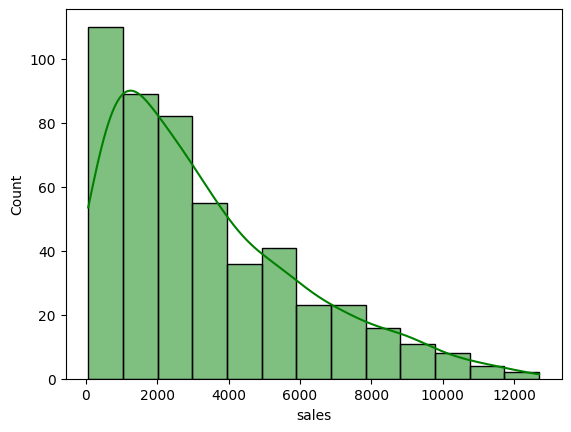

In [11]:
import seaborn as sns
sns.histplot(df['sales'],kde=True,color='g')

<Axes: >

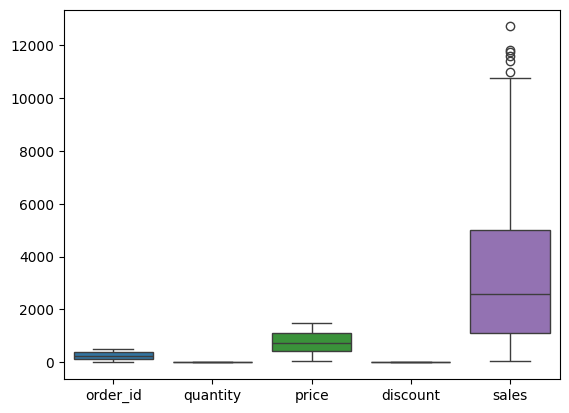

In [12]:
sns.boxplot(df)

In [13]:
df.columns

Index(['order_id', 'date', 'region', 'product', 'category', 'customer_type',
       'quantity', 'price', 'discount', 'sales'],
      dtype='str')

In [14]:
df

,order_id,date,region,product,category,customer_type,quantity,price,discount,sales
0,1,2024-04-12,East,Laptop,Electronics,Returning,8,590,0.09,4295.20
1,2,2024-12-14,South,Monitor,Accessories,Returning,2,262,0.18,429.68
2,3,2024-09-27,North,Phone,Accessories,New,5,512,0.09,2329.60
3,4,2024-04-16,West,Mouse,Electronics,Returning,1,485,0.09,441.35
4,5,2024-03-12,West,Phone,Electronics,Returning,7,332,0.22,1812.72
...,...,...,...,...,...,...,...,...,...,...
495,496,2024-11-20,South,Mouse,Accessories,Returning,6,314,0.23,1450.68
496,497,2024-01-04,North,Phone,Accessories,Returning,9,369,0.23,2557.17
497,498,2024-01-16,South,Keyboard,Electronics,Returning,6,722,0.14,3725.52
498,499,2024-10-06,North,Phone,Accessories,Returning,2,1449,0.12,2550.24


In [15]:
df.drop(['order_id','date','discount'],axis=1,inplace=True)

In [16]:
df.select_dtypes(include=['int','float']).corr()

,quantity,price,sales
quantity,1.000000,0.082232,0.692406
price,0.082232,1.000000,0.668516
sales,0.692406,0.668516,1.000000


In [17]:
df.describe()

,quantity,price,sales
count,500.000000,500.000000,500.000000
mean,4.968000,768.158000,3333.059560
std,2.569081,404.010497,2693.185995
min,1.000000,50.000000,67.320000
25%,3.000000,432.750000,1120.867500
50%,5.000000,742.000000,2582.805000
75%,7.000000,1094.500000,4998.030000
max,9.000000,1499.000000,12700.800000


In [18]:
# drop outliers
Q1=df['sales'].quantile(0.25)
Q3=df['sales'].quantile(0.75
                        )
IQR=Q3-Q1


In [19]:
Q1

np.float64(1120.8675)

In [20]:
Q3

np.float64(4998.030000000001)

In [21]:
IQR

np.float64(3877.1625000000004)

In [22]:
df.shape

(500, 7)

In [23]:

# Define lower and upper limits for outliers
lower_limit = Q1 - 1 * IQR  #1.5 repersent Standard outlier detection increase or decrees csz extreme or too many values removed
upper_limit = Q3 + 1 * IQR

# Remove rows where sales value is outside the limits
df_clean = df[(df['sales'] >= lower_limit) & (df['sales'] <= upper_limit)]

# Print number of rows after removing outliers
print("Rows after removing outliers:", len(df_clean))

Rows after removing outliers: 476


In [24]:
print('lower limit/ extreme low values',lower_limit)
print('upper limit/ extreme hingh values',upper_limit)



lower limit/ extreme low values -2756.295
upper limit/ extreme hingh values 8875.192500000001


<Axes: >

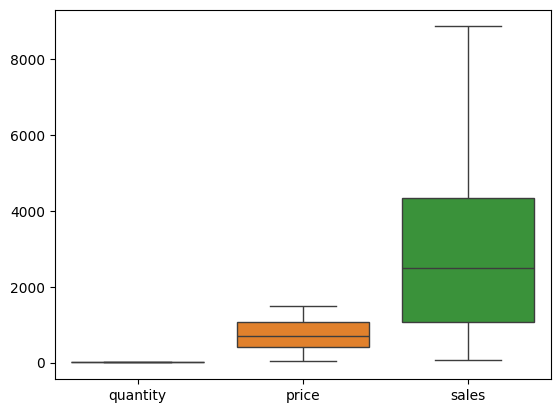

In [25]:
sns.boxplot(df_clean)

In [26]:
df_clean.head()

,region,product,category,customer_type,quantity,price,sales
0,East,Laptop,Electronics,Returning,8,590,4295.20
1,South,Monitor,Accessories,Returning,2,262,429.68
2,North,Phone,Accessories,New,5,512,2329.60
3,West,Mouse,Electronics,Returning,1,485,441.35
4,West,Phone,Electronics,Returning,7,332,1812.72


In [27]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df_clean['customer_type']=le.fit_transform(df_clean.customer_type)
df_clean

,region,product,category,customer_type,quantity,price,sales
0,East,Laptop,Electronics,1,8,590,4295.20
1,South,Monitor,Accessories,1,2,262,429.68
2,North,Phone,Accessories,0,5,512,2329.60
3,West,Mouse,Electronics,1,1,485,441.35
4,West,Phone,Electronics,1,7,332,1812.72
...,...,...,...,...,...,...,...
495,South,Mouse,Accessories,1,6,314,1450.68
496,North,Phone,Accessories,1,9,369,2557.17
497,South,Keyboard,Electronics,1,6,722,3725.52
498,North,Phone,Accessories,1,2,1449,2550.24


In [28]:
df_clean=pd.get_dummies(df_clean)
df_clean.head()

,customer_type,quantity,price,sales,region_East,region_North,region_South,region_West,product_Keyboard,product_Laptop,product_Monitor,product_Mouse,product_Phone,product_Tablet,category_Accessories,category_Electronics
0,1,8,590,4295.20,True,False,False,False,False,True,False,False,False,False,False,True
1,1,2,262,429.68,False,False,True,False,False,False,True,False,False,False,True,False
2,0,5,512,2329.60,False,True,False,False,False,False,False,False,True,False,True,False
3,1,1,485,441.35,False,False,False,True,False,False,False,True,False,False,False,True
4,1,7,332,1812.72,False,False,False,True,False,False,False,False,True,False,False,True


In [29]:
df_clean.shape

(476, 16)

In [30]:
df_clean.columns

Index(['customer_type', 'quantity', 'price', 'sales', 'region_East',
       'region_North', 'region_South', 'region_West', 'product_Keyboard',
       'product_Laptop', 'product_Monitor', 'product_Mouse', 'product_Phone',
       'product_Tablet', 'category_Accessories', 'category_Electronics'],
      dtype='str')

In [31]:
X=df_clean.drop('sales',axis=1) #features columns 
y=df_clean['sales'] #target column
X.columns

Index(['customer_type', 'quantity', 'price', 'region_East', 'region_North',
       'region_South', 'region_West', 'product_Keyboard', 'product_Laptop',
       'product_Monitor', 'product_Mouse', 'product_Phone', 'product_Tablet',
       'category_Accessories', 'category_Electronics'],
      dtype='str')

In [32]:
#data split in trian and test

x_train,x_test,y_trian,y_test=train_test_split(X,y,test_size=0.2,
                                               random_state=42)


In [33]:
model=LinearRegression()
model.fit(x_train,y_trian)



y_pred=model.predict(x_test)

In [34]:
x_test.head()

,customer_type,quantity,price,region_East,region_North,region_South,region_West,product_Keyboard,product_Laptop,product_Monitor,product_Mouse,product_Phone,product_Tablet,category_Accessories,category_Electronics
491,1,8,725,False,False,True,False,True,False,False,False,False,False,True,False
38,1,4,351,False,True,False,False,False,False,False,True,False,False,True,False
139,1,7,127,False,False,True,False,True,False,False,False,False,False,False,True
79,0,5,237,True,False,False,False,False,False,False,False,True,False,False,True
85,0,7,632,True,False,False,False,True,False,False,False,False,False,False,True


In [35]:
y_test

491    4118.00
38     1151.28
139     880.11
79     1042.80
85     3273.76
        ...   
148      79.20
47     7063.20
263    7581.91
404    2246.94
307    1712.00
Name: sales, Length: 96, dtype: float64

In [36]:
y_pred

array([ 4734.18998318,   970.77564088,  2044.07226682,  1093.77069632,
        3852.35720941,  6657.03122195,  6062.5507659 ,  3235.72103792,
         663.43837078,  -276.49222017,  5302.84894433,  3122.48395022,
         757.80756667,  6612.8863234 ,  1233.88695368,  3962.66228439,
        6123.18668591,  3792.53084975,   620.00401536,  -612.2857623 ,
         500.22364963,  3130.34463646,  1941.33558762,  7579.70095734,
        4290.85512271,  3928.1829365 ,   604.89005611,  2520.28698215,
        5396.70835285,  2314.81430464,  3408.755456  ,  1480.10897049,
        6251.98029746,  3669.27858244,  2193.17773459, -1035.91191427,
        4664.78079472,  4677.98599261,  2028.52841671,  5051.41065812,
        5144.41627521,  3753.48906741,  3460.25088989,  2129.76405937,
        3690.17046675,   527.14386627,  1489.36438687,  2777.04784292,
        3349.37306111,  5609.28172437,   371.14520391,  -287.59401068,
        2246.06942475,  -429.40414035,  4873.97616653,  6476.37913082,
      

In [37]:
from sklearn.metrics import r2_score,root_mean_squared_error

print('accucry of model ',r2_score(y_test,y_pred))

accucry of model  0.8502810939370058


<Axes: xlabel='sales'>

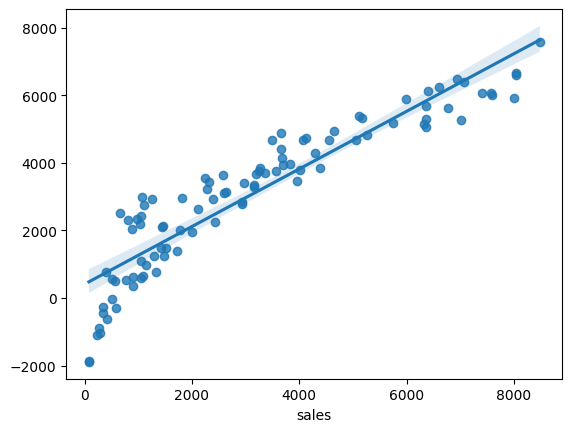

In [38]:
sns.regplot(x=y_test,y=y_pred)

In [39]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_poly_train = poly.fit_transform(x_train)
X_poly_test = poly.transform(x_test)

In [40]:
poly_model = LinearRegression()

poly_model.fit(X_poly_train, y_trian)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:

y_pred_poly = poly_model.predict(X_poly_test)
from sklearn.metrics import r2_score, mean_squared_error

print("Polynomial R2:", r2_score(y_test, y_pred_poly))
print("Polynomial MSE:", mean_squared_error(y_test, y_pred_poly))

Polynomial R2: 0.9703425863420824
Polynomial MSE: 164267.05165549504


In [42]:
y_pred_poly

array([4860.54532145, 1314.07142964,  764.57924645, 1236.73734511,
       3943.07891406, 8337.84017172, 6339.87685056, 2284.49321988,
       1214.34605037,  145.69878513, 6076.30553842, 2265.57182865,
       1395.81722934, 7463.91800556, 1436.49778484, 3812.86444906,
       6794.47534948, 3400.03849194, 1110.99975099,  376.50085787,
        158.94969998, 2449.39590915, 1880.37775807, 9265.34867606,
       3765.31086546, 3986.6788838 ,  962.75218487,  659.45593216,
       5337.85869805,  968.92606299, 2907.11947721, 1173.31197756,
       6941.35993051, 3009.70146878, 1012.86373033,  277.20092289,
       4630.18910608, 3562.90451525, 1934.51043855, 5989.62732907,
       5634.1166571 , 2991.13636291, 3390.39626026, 1902.81758611,
       3321.59205256,  865.35276614, 1849.0038443 , 2822.31831933,
       3659.38182443, 6491.86766348, 1049.54340118,  794.02836476,
       2468.23357167,  232.3047046 , 4086.21458484, 7288.16105196,
       3902.53537963, 3270.93654841, 6180.09139727, 4261.04332

<Axes: xlabel='sales'>

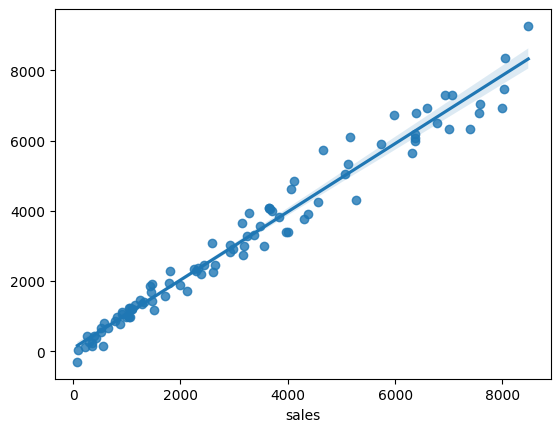

In [43]:
sns.regplot(x=y_test,y=y_pred_poly)